## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

- Ari Swerdlow: Writing - original draft, Writing - review & editing
- Conner Satawidinata: Conceptualization, Background research, Writing - review & editing, Data curation
- George Minasyan: Project administration, Writing - review & editing
- Ghaida Alruwais: Writing - original draft, Data curation, Merging datasets 
- Guthry Hahm: Writing - original draft, Writing - review & editing

# Research Question

Which factors predict NBA MVP voting share from 1996 to 2022, and how has their importance shifted across the eras?

- Which player statistics (points, assists, rebounds) and advanced efficiency metrics (BPM, Win Shares/48) are the strongest predictors of MVP vote share across the entire 1996-2022 period?
- How does the predictive importance of traditional versus advanced metrics differentiate between the pre-analytics era (1996-2004) and modern era (2004-2022)?

Our dataset will likely combine per-game player statistics from Kaggle using manually added MVP vote sharing data from Basketball Reference. This means this will be mainly a prediction + statistical inference task, and would require us to use regression-based models in order to count each statistic’s contribution to the vote share, and then compare the importance of features across both eras to identify whether the “MVP profile” changed alongside advanced analytics becoming mainstream.


## Background and Prior Work

The National Basketball Association (NBA) is the predominant professional basketball league in the United States. When people talk about the NBA, a common point of discussion is who the face of the league is. A tangible way to assign this title is by looking at which player is awarded the league MVP for each NBA season. The MVP award for the NBA was introduced in 1956, ten years after the formation of the league, with the first recipient being Bob Pettit. <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) As of the 1980-1981 NBA season, the decision of which player receives the MVP award has been through voting by members of the media. <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2) This subjective evaluation means that there is not a concrete formula that determines the MVP award recipient. 

As a result of the uncertainty in MVP voting, researchers and analysts have tried to identify which statistical factors predict MVP outcomes. Coleman and his colleagues conducted early research on the MVP races determined by media voting, specifically the seasons from 1995-2005, to form models of media voting behavior. They used a mixture of player characteristics (e.g. race and basketball position), traditional box score statistics (e.g. points, total rebounds, and assists), and team metrics (e.g. team wins and playoff qualification) to build both a Tobit and a Probit Regression model of MVP voting <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3). Alongside addressing the original question on player race impacting MVP voting behavior, the models capture the significance of the traditional box score statistics. Both models indicated that a player’s points per game (PPG) was the most significant player statistic predictor of a player appearing on the MVP ballot (Probit) and the MVP voting points the player would receive (Tobit). However, the data used to build the models did not include any advanced metrics (e.g. BPM and win shares) which highlights potential confounding variables that their models did not capture.

More recent research by Li and Jia applies machine learning to identify the statistical features that best predict MVP outcomes. They utilized a dataset with both traditional and advanced metrics for NBA players from 1974 to 2024 to build the five machine learning models of Random Forest, LightGBM, XGBoost, CatBoost, and NGBoost. By considering a mixture of minimizing MSE and time consumption while maximizing the R-squared coefficient, CatBoost was found to be the optimal model <a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4). SHAP value analysis was used after further training of the CatBoost model to find that the most important predictors of the CatBoost’s player value scores are value over replacement player (VORP), points per game, and player efficiency rating (PER). These findings emphasize the importance of including advanced metrics in addition to traditional box score statistics in predicting MVP share. Yet, the treating of the data as a single time period leaves room for analysis across different eras and years.

Godbole and his colleagues explored MVP prediction further by training an ensemble of machine learning models across the three distinct NBA eras of the Ancient Era (1990-91 to 1999-00), the Medieval Era (2000-01 to 2011-12), and the Modern Era (2012-13 to 2021-22). They applied the five machine learning models of Support Vector Regression (SVR), ElasticNet, Adaptive Boosting, Random Forest, and Gradient Boosting as well as a backpropagation neural network that they named MVPNet. MVPNet outperformed all other models, achieving an R-squared coefficient of 0.86 and correctly predicting 10 out of 10 Modern Era MVPs <a name="cite_ref-5"></a>[<sup>5</sup>](#cite_note-5). SHAP analysis revealed that team statistics such as win percentage and seeding were the most important predictors in earlier eras, while advanced metrics grew more influential in the Modern Era. Although the study addresses how the predictive importance of statistics has shifted over time within each era, the primary focus of the study was on comparing how current players would perform in the MVP race across different eras.

While these studies deepen the understanding of MVP prediction, their scopes do not focus on the continuity or change of MVP voting over time. Since the complete tracking of advanced metrics in the 1996-1997 season, the relative importance of these statistics compared to traditional box score statistics has not been clearly established <a name="cite_ref-6"></a>[<sup>6</sup>](#cite_note-6). Numerous sports analysts have debated which performance statistics best capture player value. A particularly influential work is Dean Oliver’s 2004 publication Basketball On Paper: Rules and Tools for Performance Analysis, in which he introduced the “Four Factors of Winning” as effective field goal percentage, offensive rebound rate, turnover percentage, and free throw rate <a name="cite_ref-7"></a>[<sup>7</sup>](#cite_note-7). This suggests a transition toward efficiency rather than traditional counting stats, highlighting a potential turning point in how player performance is assessed for MVP voting. By using 2004 as a formal pivot point, we can test whether Oliver’s 'Four Factors' acted as a catalyst for media voters. While the 'Medieval' and 'Modern' eras are often grouped, our project specifically seeks to identify if 2004 was the precise moment the 'Points-Per-Game' dominance began to decay in favor of the efficiency-weighted profile Oliver championed. We are trying to capture how the predictive strength in advanced metrics compared to traditional box score statistics in gaining MVP vote share has changed over the time period spanning the 1996-1997 NBA season to the 2021-2022 NBA season.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) "NBA MVPs: Complete List of Award Winners by Year." *Fox Sports*, 2 June 2025, https://www.foxsports.com/stories/nba/nba-mvps-complete-list-of-award-winners-by-year. 
2. <a name="cite_note-2"></a> [^](#cite_ref-2) "NBA Awards Voting 2025-26." *Basketball Reference*, https://www.basketball-reference.com/awards/awards_2026.html. 
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Coleman, B. Jay, et al. "An Examination of NBA MVP Voting Behavior: Does Race Matter?" *Journal of Sports Economics*, vol. 9, no. 6, 2008, pp. 606–627, https://digitalcommons.unf.edu/cgi/viewcontent.cgi?article=1003&context=bmgt_facpub. 
4. <a name="cite_note-4"></a> [^](#cite_ref-4) Li, Zeyang, and Lei Jia. "NBA Most Valuable Player Projection Model: Based on Traditional and Advanced Metrics." *2024 International Conference on Sports Technology and Performance Analysis* (*ICSTPA 2024*), ACM, 2024, https://dl.acm.org/doi/full/10.1145/3723936.3723963.
5. <a name="cite_note-5"></a> [^](#cite_ref-5) Godbole, Ishan, et al. "NBA MVP Prediction and Historical Analysis Using Cross-Era Comparison Approaches." *2024 15th International Conference on Computing Communication and Networking Technologies (ICCCNT)*, IEEE, 2024, https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=10725534.
6. <a name="cite_note-6"></a> [^](#cite_ref-6) "NBA.com/Stats Frequently Asked Questions." *NBA.com*, https://www.nba.com/stats/help/faq. 
7. <a name="cite_note-7"></a> [^](#cite_ref-7) Oliver, Dean. *Basketball on Paper: Rules and Tools for Performance Analysis*. Potomac Books, 2004.  


# Hypothesis


- During 1996-2022, win shares per 48 minutes will be the strongest MVP vote share predictor, followed by points per game.

We expect win shares per 48 minutes to be the strongest MVP voter share predictor because it estimates the number of wins a player contributes to their team per 48 minutes, indicating whether a player’s performance is actually valuable to winning as opposed to just being high counting statistics with no real impact. We also expect points per game to be the next strongest predictor because high scoring output is the most visible aspect of a player’s game which would create a positive perception of the player by media voters.

- We predict advanced efficiency metrics (BPM, PER, TS%, etc) are stronger predictors of MVP vote share than traditional box score statistics (points, rebounds, assists, etc) in the modern era (2004-2022) than the pre-analytics era (1996-2004).
  
Although advanced metrics were introduced in 1996, we believe media voters would not readily adopt these new statistics in their MVP voting rationale. The introduction of Dean Oliver’s “Four Factors to Winning” likely changed the way advanced metrics were perceived, leading to greater credibility of advanced metrics for media voters. As a result, we predict that voters began to value the efficiency captured through advanced metrics more than the traditional counting statistics in the post-2004 era. This shift in voter focus was potentially reinforced by the 2004 elimination of hand-checking, which fundamentally changed scoring dynamics and made perimeter efficiency a more visible driver of team success.


## Data

### Data overview

- Dataset #1
  - Dataset Name: NBA Players Biometric, Biographic and Basic Box Score Data (1996-2022)
  - Link to the dataset: https://www.kaggle.com/datasets/justinas/nba-players-data
  - Number of observations: 12,844
  - Number of variables: 22 
  - Description of the variables most relevant to this project:
     - player_name - The full name of the player which will be used alongside the specific season and the team the player was on for that season as the key for merging datasets.
     - team_abbreviation - The team the player finished a specific season on which can be used alongside the player name as the key for merging datasets.
     - gp (Games Played) - The number of games the player played during that season. 
     - pts, reb, ast - Per-game averages for points, rebounds, and assists which are core traditional box score statistics.
     - net_rating - An estimate of a team's point differential per 100 possessions while the player is on the court.
     - usg_pct (Usage Percentage) - An estimate of the proportion of team plays that a player was involved in while on the floor.
     - ts_pct (True Shooting Percentage) - A composite shooting efficiency metric that accounts for 2-pointers, 3-pointers, and free throws. The values range from 0% to 100% with a higher percentage indicating more greater efficiency scoring.
     - oreb_pct (Offensive Rebound Percentage)  - An estimate of the proportion of offensive rebounds that a player actually grabbed from the offensive rebound opportunities. The values range from 0% to 100% with a higher percentage indicating greater impact in offensive rebounding.
     - dreb_pct (Defensive Rebound Percentage) - An estimate of the proportion of defensive rebounds that a player actually grabbed from the defensive rebound opportunities. The values range from 0% to 100% with a higher percentage indicating greater impact in defensive rebounding.
     - season - The NBA season (e.g. "1996-97") that the per game stats and advanced metrics are drawn from.
  - Descriptions of any shortcomings this dataset has with respect to the project:
     - The dataset does not have an MVP vote share column which requires this target variable to be merged in from a separate dataset.
     - The dataset does not have any variables to track the qualitative aspects of each player’s seasons which restricts the ability to capture the impact of media narratives and stores on MVP vote share.
     - The dataset is missing some key advanced metrics, such as Value Over Replacement Player (VORP) and Box Plus Minus (BPM) that we want to analyze the predictive strength for MVP vote share of.
     - The dataset is missing a few key traditional box score statistics, such as turnovers per game, blocks per game, and steals per game which requires merging these stats in from a separate dataset.
     - The dataset does not contain the position (e.g. PG, SG, SF, PF, C) that each player plays which restricts the ability to control potential voting bias for each basketball position.
     - The dataset contains stats for all NBA players, including players who only played a single game for a particular season, which may create noise for advanced metrics like net rating which will rely on scaling upward the small game sample size of said players.

- Dataset #2
  - Dataset Name: NBA MVP Voting Data (1996-2022)
  - Link to the dataset: https://www.basketball-reference.com/awards/awards_1997.html (replace [1997] with any year from 1997-2022 to get all years)
  - Number of observations: 386
  - Number of variables: 21
  - Description of the variables most relevant to this project:
    - player - Full name of the player receiving MVP votes which is used as the primary key for merging with the other datasets alongside team and season.
    - tm - Three letter team abbreviation for the team that the player ended on during that season and can be used alongside player and season as part of the merge key.
    - share - The proportion of total possible MVP voting points a player received (ranging from 0 to 1). This is the target variable for all regression models in the project. 
    - season - The NBA season label (e.g., "1996-97") that the MVP voting is for which is used for merging and for splitting observations into pre-analytics (1996–2004) and modern (2004–2022) eras. 
  - Descriptions of any shortcomings this dataset has with respect to the project:
    - The dataset only includes players who received an MVP vote for a specific season which requires additional attention to fill out the vote shares of non-MVP vote-getters to be 0 when merging datasets.
    - The dataset does not have any variables that indicate the team success of each player (e.g. team wins/team net rating) which restricts the ability to track team statistics as confounding variables of MVP vote share.
    - Similar to the Kaggle dataset, this dataset does not have any statistics that track the narrative or stories around a player’s season which also restricts the ability to track media narrative as a confounding variable of MVP vote share.
    - Similar to the Kaggle dataset, this dataset is missing some key advanced metrics, such as Value Over Replacement Player (VORP) and Box Plus Minus (BPM) that we want to analyze the predictive strength for MVP vote share of.

- Dataset #3
  - Dataset Name: NBA Traditional Box Score Per Game Stats (1996-2022)
  - Link to the dataset: https://www.basketball-reference.com/leagues/NBA_1997_per_game.html (replace [1997] with any year from 1997-2022 to get all years)
  - Number of observations: 15,398
  - Number of variables: 32
  - Description of the variables most relevant to this project:
    - Rk - The embedded index of each player in the table to help differentiate between players with the same name.
    - Player - Full name of the player that the season statistics are linked to which is used as the primary key for merging with the other datasets alongside team and season.
    - Team - The three letter team abbreviation for the team that the player was on when the stats were recorded. Players who were traded during the season have placeholders like “2TM” and “3TM” for overall season stats and individual rows for stats recorded on each individual team.
    - G - The number of games that player played in for that particular season.
    - Pos - The player's listed position (e.g., PG, SG, SF, PF, C) which can allow positional bias in MVP voting to be controlled for in regression models.
    - STL, BLK - Per-game averages for steals, and blocks which are core traditional box score defensive statistics.
    - TOV - Turnovers per game which is a traditional metric capturing a player’s ball security.
    - eFG% (Effective Field Goal Percentage) - An efficiency metric, calculated as (FG + 0.5 * 3P) / (FGA),  that adjusts for the greater number of points linked to 3-pointers as opposed to the 2 points from regular field goals and is one of Dean Oliver’s Four Factors of Winning Basketball.
    - season - The NBA season label (e.g., "1996-97") that the per game traditional box score statistics is for which is used for merging and for splitting observations into pre-analytics (1996–2004) and modern (2004–2022) eras. 
  - Descriptions of any shortcomings this dataset has with respect to the project:
    - Players who changed teams during a particular season (i.e. due to mid-season trades) have multiple entries for that season which requires keeping only the row with the player’s aggregate season per game stats while replacing the team entry with the team the player ended on to ensure proper merging.
    - As a supplemental dataset focused solely on traditional per-game statistics, advanced metrics such as VORP, Win Shares, and BPM are still absent and must be merged in from a fourth dataset. 

- Dataset #4
  - Dataset Name: NBA Advanced Player Stats (1996-2022)
  - Link to the dataset: https://www.basketball-reference.com/leagues/NBA_1997_advanced.html (replace [1997] with any year from 1997-2022 to get all years)
  - Number of observations: 15,398
  - Number of variables: 30
  - Description of the variables most relevant to this project:
    - Rk - The embedded index of each player in the table to help differentiate between players with the same name.
    - Player - Full name of the player that the season statistics are linked to which is used as the primary key for merging with the other datasets alongside team and season.
    - Team - The three letter team abbreviation for the team that the player was on when the stats were recorded. Players who were traded during the season have placeholders like “2TM” and “3TM” for overall season stats and individual rows for stats recorded on each individual team.
    - G - The number of games that player played in for that particular season.
    - PER (Player Efficiency Rating) - A per-minute rating of a player’s performance that sums up all a player's positive accomplishments while subtracting the negative accomplishments. The average PER is 15.
    - WS/48 (Win Shares Per 48 Minutes) - An estimate of the number of wins contributed by the player per 48 minutes with the league average being approximately 0.100.
    - TOV% - An estimate of the number of turnovers a player commits per 100 possessions and is one of Dean Oliver’s Four Factors of Winning Basketball.
    - FTr (Free Throw Rate) - The number of free throws a player attempts per field goal attempt and is one of Dean Oliver’s Four Factors of Winning Basketball.
    - VORP (Value Over Replacement Player) - An estimate of the number of points per 100 possessions that a player contributes to their team over a replacement player who has a -2.0 BPM.
    - BPM (Box Plus Minus) - An estimate of a player’s contribution of points per 100 possessions over a league-average player. The average BPM is 0.0.
    - season — The NBA season label (e.g., "1996-97") that the advanced metric statistics are collected for which is used for merging and for splitting observations into pre-analytics (1996–2004) and modern (2004–2022) eras. 
  - Descriptions of any shortcomings this dataset has with respect to the project:
    - Advanced metrics like VORP and BPM are very volatile if a player's game sample size is low which may create artifically high or low values for players with little playing time.
    - Similar to the Traditional Box Score Per Game Stats dataset, this dataset also contains multiple entries for players who switched teams during a particular season, requiring the same deduplication approach of keeping only the aggregate row and replacing the team with the team they finished on. 
    - This dataset still contains no team success variables, meaning team metrics like win totals and team standing must be scraped separately.


- Merging Datasets

The four datasets are merged into a single central dataset using a two-part key of player name and season. If needed, the embedded Rk index of the basketball reference datasets or the 3 letter team abbreviation present in all datasets will be used as a tertiary merging key. Prior to merging, each dataset requires deduplication of players who switched teams mid-season by retaining only the aggregate season row and replacing the team entry with the team the player finished the season on, in order to be consistent with the Kaggle NBA Players Biometric, Biographic, and Basic Box Score dataset. Each dataset will also be subset to retain only the relevant variables and merge key columns, preventing duplication of player metrics in the final dataset. The subsetted data sets will then be checked for tidiness and cleaned prior to merging to ensure that the final merged dataset is tidy and clean. Additionally, each dataset will have to have their columns to merge on renamed to be consistent across all four datasets. The Kaggle player stats dataset is used as the base for the merge, with non-vote-getters assigned a vote share of 0 after joining with the MVP voting dataset, the per-game traditional box score dataset, and the advanced stats dataset. 


In [2]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [3]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
import time
import pandas as pd
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=16lrGv8z2WbtL7aG6RkngNM03miR3RhGq', 'filename': 'all_seasons.csv'}
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:02<00:00,  2.35s/it]

Successfully downloaded: all_seasons.csv


### Dataset: Kaggle NBA Players Biometric, Biographic, and Basic Box Score Data (1996–2022)

The Kaggle dataset serves as the foundation of the merged modeling dataset by providing some per-season traditional box score statistics and advanced efficiency metrics for all NBA players across the 1996–2022 period. The core traditional statistics included are points (pts), rebounds (reb), and assists (ast) which are all measured as per-game averages across the season. Points per game is the most direct measure of a player's scoring output, with any averages exceeding 25 points per game being considered elite scoring output. Rebounds per game captures a player's ability to secure the basketball following a missed shot by either team with elite rebounders averaging above 10 rebounds per game. Assists per game measures a player's ability to create scoring opportunities for teammates through passing the basketball with players being considered elite playmakers/floor generals when they average above 8 assists per game. There is also a games played (gp) statistics which allows for the creation of potential subsets of players if players who barely play any games are creating a lot of noise for the model.

The dataset also includes several advanced efficiency metrics which tell a story beyond traditional box score statistics. True shooting percentage (ts_pct) measures overall scoring efficiency as a single percentage that combines two-point field goals, three-point field goals, and free throws. The league average of true shooting percentage typically falls around 55% with elite efficiency attributed to players exceeding 60%. Usage percentage (usg_pct) estimates the proportion of team possessions a player is involved in while on the floor, indicating how integral a player is to their team’s offense. Usage percentage values typically range from 15% for role players to above 35% for primary offensive options. Net rating (net_rating) is an estimate of a team's point differential per 100 possessions while a specific player is on the court. Positive net rating values indicate the team outscores opponents with the player on the floor and negative values indicate the team gets outscored with the player on the floor. Offensive and defensive rebound percentages (oreb_pct and dreb_pct) estimate the proportion of offensive and defensive rebounds a player secures from the available opportunities, with elite offensive rebounders exceeding 15% and elite defensive rebounders exceeding 25%.

While the dataset provides a strong foundation of traditional and efficiency metrics, it still carries concerns due to not capturing the entire picture of the season statistics of NBA players. Several variables central to the research question, including BPM, VORP, positional data, and team success metrics, are missing. This requires sourcing from the supplemental Basketball Reference datasets before any modeling can be conducted. Additionally, the presence of all NBA players in the dataset when only a small percentage of NBA players actually get MVP votes in a season results in a zero-heavy distribution in terms of MVP vote share which may require further stratification. Furthermore, the presence of all NBA players may create heavy noise for the advanced metrics, such as net rating and true shooting percentage, because advanced metrics are scaled upward which may suffer from players who have a very small game sample size.

====================== TIDINESS CHECK ======================
Raw Dataframe Head:
   Unnamed: 0       player_name team_abbreviation   age  player_height  \
0           0  Randy Livingston               HOU  22.0         193.04   
1           1  Gaylon Nickerson               WAS  28.0         190.50   
2           2      George Lynch               VAN  26.0         203.20   
3           3    George McCloud               LAL  30.0         203.20   
4           4      George Zidek               DEN  23.0         213.36   

   player_weight                college country draft_year draft_round  ...  \
0      94.800728        Louisiana State     USA       1996           2  ...   
1      86.182480  Northwestern Oklahoma     USA       1994           2  ...   
2     103.418976         North Carolina     USA       1993           1  ...   
3     102.058200          Florida State     USA       1989           1  ...   
4     119.748288                   UCLA     USA       1995           1  ...   


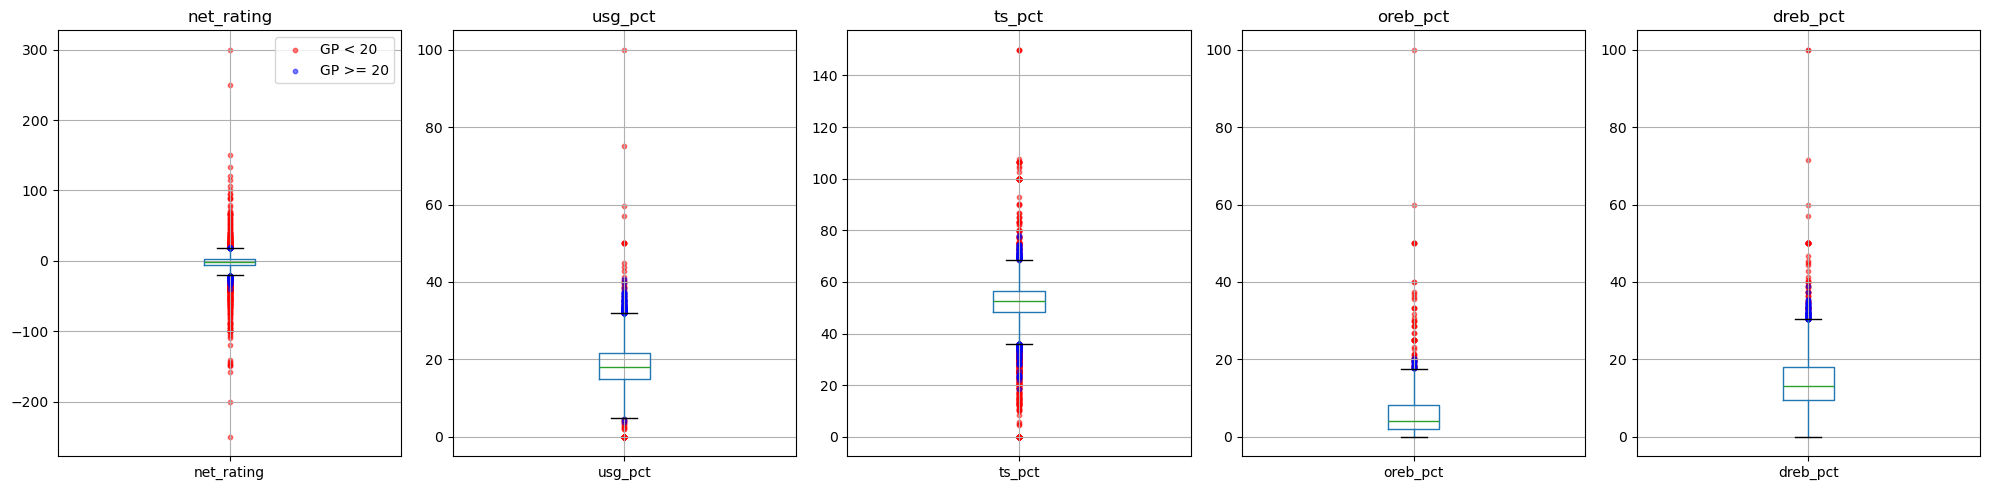

Most extreme outliers are a result of players with very few games played in a season so we will remove all players with fewer than 20 games played.
Rows after games played filtering: 10720
Create box plots for these five advanced metrics to visualize outliers after games played filtering


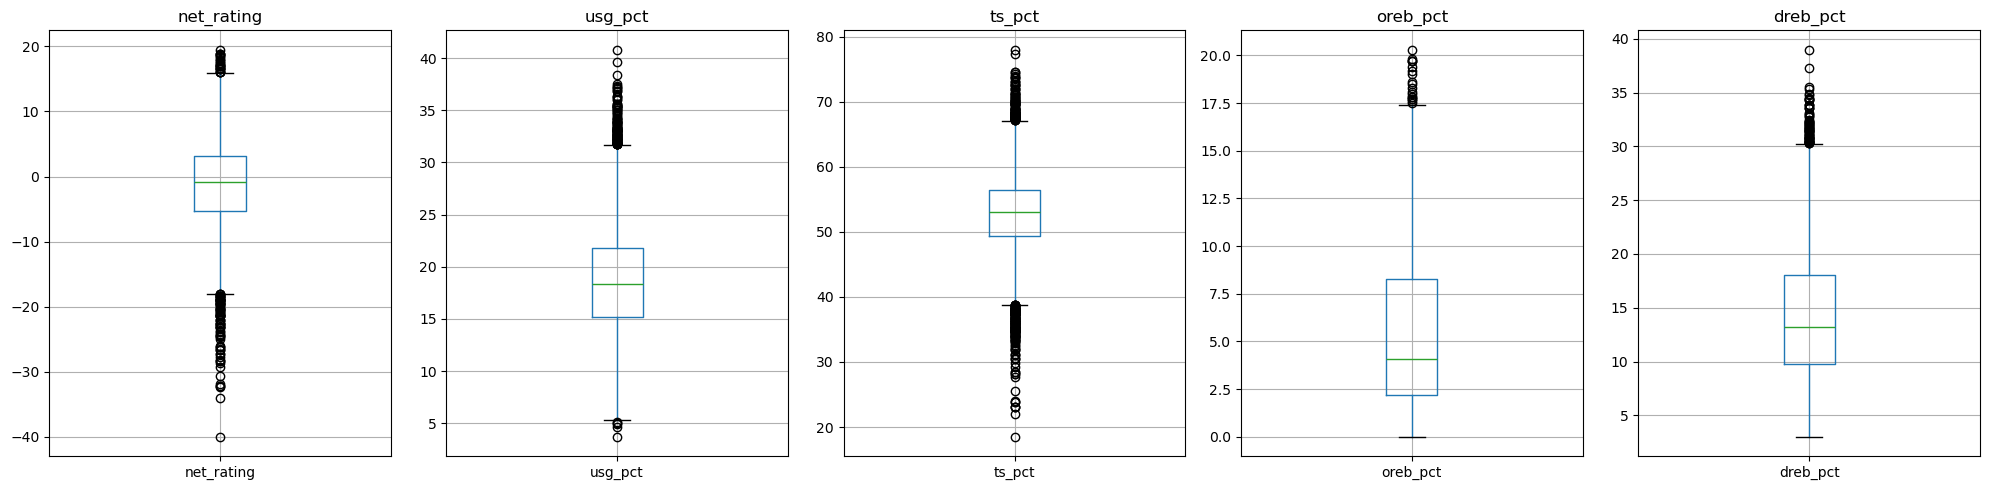

Remaining outliers after filtering out low games played rows represent legitimate high-performing or low-performing players with sufficient sample sizes and are not removed.
====================== CLEANLINESS CHECK ======================
Check for invalid team abbreviations:
<StringArray>
['HOU', 'VAN', 'LAL', 'DEN', 'ORL', 'WAS', 'CHH', 'MIL', 'DET', 'POR', 'DAL',
 'UTA', 'SEA', 'BOS', 'SAS', 'MIA', 'ATL', 'NJN', 'LAC', 'IND', 'GSW', 'NYK',
 'PHI', 'TOR', 'PHX', 'MIN', 'CHI', 'SAC', 'CLE', 'MEM', 'NOH', 'CHA', 'NOK',
 'OKC', 'BKN', 'NOP']
Length: 36, dtype: str
All team abbreviations are valid, accepted 3 letter codes.
Check for invalid season entries:
<StringArray>
['1996-97', '1997-98', '1998-99', '1999-00', '2000-01', '2001-02', '2002-03',
 '2003-04', '2004-05', '2005-06', '2006-07', '2007-08', '2008-09', '2009-10',
 '2010-11', '2011-12', '2012-13', '2013-14', '2014-15', '2015-16', '2016-17',
 '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Length: 27, dtype: str


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in data
data_path = 'data/00-raw/all_seasons.csv'
df_all_seasons = pd.read_csv(data_path)

# demonstrate tidiness
print("====================== TIDINESS CHECK ======================")
print ("Raw Dataframe Head:") 
print(df_all_seasons.head())
print(f"Dataframe shape: {df_all_seasons.shape}")
print(f"The number of rows that have the same player, season, and team abbreviation: {df_all_seasons[['player_name', 'team_abbreviation', 'season']].duplicated().sum()}")
print("The number of rows that have a missing player or team name:")
print(df_all_seasons[['player_name', 'team_abbreviation']].isnull().sum())
print(f"The list of all column variables in the dataset: {df_all_seasons.columns}")
print("Each row represents the season statistics of a player for a particular season and each column represents a unique characteristic or statistic of the player's season.")

# demonstrate data size
print("====================== DATAFRAME SIZE ======================")
print(f"Dataframe size: {df_all_seasons.size}")
print(f"Dataframe rows: {df_all_seasons.shape[0]}")
print(f"Dataframe columns: {df_all_seasons.shape[1]}")

filtered_df_all_seasons = df_all_seasons[['player_name', 'team_abbreviation', 'gp', 'pts', 'reb', 'ast', 'net_rating', 'usg_pct', 'ts_pct', 'oreb_pct', 'dreb_pct', 'season']].copy()
print ("Dataframe Head After Selecting Target Columns:")
print(filtered_df_all_seasons.head())

# find out how much data is missing
print("====================== MISSINGNESS CHECK ======================")
print(f"Total amount of missing data: {filtered_df_all_seasons.isna().sum().sum()}")
print("No missing entries in the target columns for this dataset.")

# find and deal with outliers/suspicious entries
print("====================== SUSPICIOUS ENTRIES CHECK ======================")
print("Show descriptive statistics.")
print(filtered_df_all_seasons.describe())
print("Descriptive statistics show no impossible values for the numerical metrics because there are no negative values besides net rating and all percentages do not exceed proportion 1.00 besides true shooting percentage which can have up to a max value of proportion 1.50.")
print("Descriptive statistics also show the percentage columns are represented as decimals and must be transformed to percentages.")
pct_cols = ['ts_pct', 'oreb_pct', 'dreb_pct', 'usg_pct']

filtered_df_all_seasons[pct_cols] = (filtered_df_all_seasons[pct_cols] * 100).round(1)
print("Show descriptive statistics after percentage transform.")
print(filtered_df_all_seasons.describe())
print("Descriptive statistics call attention to potential outliers in the advanced metric columns of net_rating, usg_pct, ts_pct, oreb_pct, and dreb_pct.")
print("Create box plots for these five advanced metrics to visualize outliers and color code based on games played")
cols = ['net_rating', 'usg_pct', 'ts_pct', 'oreb_pct', 'dreb_pct']
fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for ax, col in zip(axes, cols):
    # plot the boxplot without outlier markers
    filtered_df_all_seasons.boxplot(column=col, ax=ax, showfliers=False)
    
    # calculate IQR to identify outlier points
    Q1 = filtered_df_all_seasons[col].quantile(0.25)
    Q3 = filtered_df_all_seasons[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = filtered_df_all_seasons[
        (filtered_df_all_seasons[col] < Q1 - 1.5 * IQR) | 
        (filtered_df_all_seasons[col] > Q3 + 1.5 * IQR)
    ]
    
    # color outliers by games played threshold
    low_gp = outliers[outliers['gp'] < 20]
    high_gp = outliers[outliers['gp'] >= 20]
    
    ax.scatter([1] * len(low_gp), low_gp[col], color='red', alpha=0.5, label='GP < 20', s=10)
    ax.scatter([1] * len(high_gp), high_gp[col], color='blue', alpha=0.5, label='GP >= 20', s=10)
    ax.set_title(col)

axes[0].legend()
plt.tight_layout()
plt.show()

print("Most extreme outliers are a result of players with very few games played in a season so we will remove all players with fewer than 20 games played.")
filtered_df_all_seasons = filtered_df_all_seasons[filtered_df_all_seasons['gp'] >= 20]
print(f"Rows after games played filtering: {filtered_df_all_seasons.shape[0]}")
print("Create box plots for these five advanced metrics to visualize outliers after games played filtering")
# Plot the boxplot with outliers after games played filter
cols = ['net_rating', 'usg_pct', 'ts_pct', 'oreb_pct', 'dreb_pct']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for ax, col in zip(axes, cols):
    filtered_df_all_seasons.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()
print("Remaining outliers after filtering out low games played rows represent legitimate high-performing or low-performing players with sufficient sample sizes and are not removed.") 

# demonstrate cleanliness
print("====================== CLEANLINESS CHECK ======================")
print("Check for invalid team abbreviations:")
print(filtered_df_all_seasons['team_abbreviation'].unique())
print("All team abbreviations are valid, accepted 3 letter codes.")
print("Check for invalid season entries:")
print(filtered_df_all_seasons['season'].unique())
print("We will drop any entries with the 2022-2023 season because it is out of scope of the project and does not match the description of the Kaggle dataset.")
filtered_df_all_seasons = filtered_df_all_seasons[filtered_df_all_seasons['season'] != '2022-23']
filtered_df_all_seasons = filtered_df_all_seasons.reset_index(drop=True)
print("Rename player_name and team_abbreviation columns to be consistent for merging later.")
filtered_df_all_seasons = filtered_df_all_seasons.rename(columns={'player_name': 'Player', 'team_abbreviation': 'Team'})
print(f"Cleaned Dataframe size: {filtered_df_all_seasons.size}")
print(f"Cleaned Dataframe rows: {filtered_df_all_seasons.shape[0]}")
print(f"Cleaned Dataframe columns: {filtered_df_all_seasons.shape[1]}")
print(f"Cleaned Dataframe missing value count: {filtered_df_all_seasons.isna().sum().sum()}")
print("Cleaned Dataframe data types:")
print(filtered_df_all_seasons.dtypes)

# save final dataset
print("====================== FINAL DATASET ======================")
print("The steps involved in the data cleaning were:")
print("1) Subset dataframe with the relevant columns.")
print("2) Transform percentage columns to true percentages and round to 1 decimal place.")
print("3) Filter out rows with fewer than 20 games played.")
print("4) Remove data from the 2022-2023 season.")
print("5) Reorder row indices.")
print("Final Clean Dataset Head:")
print(filtered_df_all_seasons.head())
filtered_df_all_seasons.to_csv('data/02-processed/all_seasons_clean.csv', index=False)

### Basketball Reference NBA MVP Voting Data (1996–2022)

We used Beautiful Soup to target the table id we need from the Basketball Reference Awards page.

The MVP voting dataset sourced from Basketball Reference serves as the source of the target variable for all regression models in this project, MVP vote share. The dataset contains MVP voting results for every season from 1996–97 to 2021–22, including all players who received at least one MVP vote in each season. 

The variable of interest in this dataset is vote share (share), which represents the proportion of total possible MVP voting points a player received in a given season, ranging from 0 to 1. A vote share of 1.0 represents a unanimous MVP selection, while values close to 0 represent a player who received only marginal support from voters. Due to the structure of NBA MVP voting where each player receives MVP points based on each media member ranking their Top 5 MVP candidates from 1st to 5th, the sum of MVP vote share during a season sums to a number larger than 1.0.  The player who ends up winning MVP typically has an MVP vote share in the range from 0.6 to 1.0, while most vote-getters fall well below 0.3.

A key concern with this dataset is that it only contains players who received at least one MVP vote, resulting in just 386 observations across 26 seasons. When merged with the Kaggle dataset as the base, all remaining NBA players will be assigned a vote share of 0, resulting in a zero-heavy distribution of the target variable. Additionally, this dataset does not contain qualitative variables surrounding the season of each MVP vote-getter which means that we cannot capture the effect of potential confounding variables like a player’s narrative by the media.

In [5]:
# !pip install bs4
import requests
from bs4 import BeautifulSoup
import os
from io import StringIO

def scrape_mvp_voting(end_year, sleep=3.5):
    url = f"https://www.basketball-reference.com/awards/awards_{end_year}.html"
    time.sleep(sleep)
    r = requests.get(url, timeout=15)
    r.raise_for_status()
    r.encoding = 'utf-8'
    soup = BeautifulSoup(r.text, 'html.parser')


    # <table class="sortable stats_table now_sortable" id="mvp" data-cols-to-freeze=",2">
    table = soup.find('table', {'id': 'mvp'})  
    # exception: if page doesn't have a table for year x
    if table is None:
        print(f'  [WARNING] no MVP table for {end_year}')
        return pd.DataFrame()
    

    df = pd.read_html(StringIO(str(table)), header=1)[0] # html table --> dataframe, use second row as the column labels
    df.columns = [c.lower().replace(' ', '_') for c in df.columns] 
    df['season'] = season_label(end_year)
    return df

MVP_RAW_PATH = 'data/00-raw/mvp_voting_raw.csv'

if os.path.exists(MVP_RAW_PATH): 
    print('MVP data already downloaded, skipping.') 
else:
    frames = []  
    for yr in range(1997, 2023): 
        try:
            frames.append(scrape_mvp_voting(yr))  
            print(f'{yr} OK')
        except Exception as e:
            print(f'{yr} ERROR: {e}') 
    
    pd.concat(frames, ignore_index=True).to_csv(MVP_RAW_PATH, index=False) 
    print(f'mvp_voting_raw.csv is ready in data/00-raw')


MVP data already downloaded, skipping.


====================== TIDINESS CHECK ======================
Raw Dataframe Head:
  rank          player  age   tm  first  pts_won  pts_max  share   g    mp  \
0    1     Karl Malone   33  UTA     63      986     1150  0.857  82  36.6   
1    2  Michael Jordan   33  CHI     52      957     1150  0.832  82  37.9   
2    3      Grant Hill   24  DET      0      376     1150  0.327  80  39.3   
3    4    Tim Hardaway   30  MIA      0      238     1150  0.207  81  38.7   
4    5       Glen Rice   29  CHH      0      134     1150  0.117  79  42.6   

   ...  trb  ast  stl  blk    fg%    3p%    ft%    ws  ws/48   season  
0  ...  9.9  4.5  1.4  0.6  0.550  0.000  0.755  16.7  0.268  1996-97  
1  ...  5.9  4.3  1.7  0.5  0.486  0.374  0.833  18.3  0.283  1996-97  
2  ...  9.0  7.3  1.8  0.6  0.496  0.303  0.711  14.6  0.223  1996-97  
3  ...  3.4  8.6  1.9  0.1  0.415  0.344  0.799  12.9  0.198  1996-97  
4  ...  4.0  2.0  0.9  0.3  0.477  0.470  0.867  10.8  0.154  1996-97  

[5 rows x 21 colu

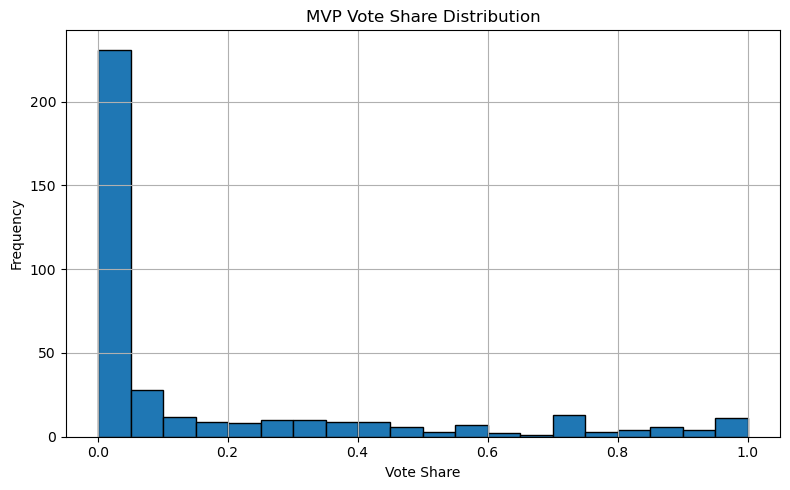

The distribution of MVP vote share is heavily right-skewed with most vote-getters receiving a very low share of votes and a small number of players receiving the bulk of votes each season.
However, this is not suspicious because there are usually only one or two true MVP contenders per season with a much greater number of players being considered for the 3rd through 5th place positions of a media members MVP voting.
====================== CLEANLINESS CHECK ======================
Check for invalid team abbreviations:
<StringArray>
['UTA', 'CHI', 'DET', 'MIA', 'CHH', 'SEA', 'HOU', 'NYK', 'LAL', 'ATL', 'SAC',
 'MIN', 'PHI', 'PHO', 'SAS', 'BOS', 'IND', 'DAL', 'WAS', 'CLE', 'POR', 'ORL',
 'TOR', 'MIL', 'NJN', 'LAC', 'NOH', 'DEN', 'TOT', 'GSW', 'OKC', 'MEM', 'CHA',
 'NOP', 'BRK']
Length: 35, dtype: str
There is a TOT team abbreviation, indicating an MVP candidate who was traded mid-season, but there is no way to retrieve the team the player ended on from this dataset alone.
The number of row

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in data
data_path = 'data/00-raw/mvp_voting_raw.csv'
df_mvp_voting = pd.read_csv(data_path)

# demonstrate tidiness
print("====================== TIDINESS CHECK ======================")
print ("Raw Dataframe Head:") 
print(df_mvp_voting.head())
print(f"Dataframe shape: {df_mvp_voting.shape}")
print(f"The number of rows that have the same player, season, and team abbreviation: {df_mvp_voting[['player', 'tm', 'season']].duplicated().sum()}")
print("The number of rows that have a missing player or team name:")
print(df_mvp_voting[['player', 'tm']].isnull().sum())
print(f"The list of all column variables in the dataset: {df_mvp_voting.columns}")
print("Each row represents the season statistics and mvp voting of a player for a particular season and each column represents a unique characteristic or statistic of the player's season.")

# demonstrate data size
print("====================== DATAFRAME SIZE ======================")
print(f"Dataframe size: {df_mvp_voting.size}")
print(f"Dataframe rows: {df_mvp_voting.shape[0]}")
print(f"Dataframe columns: {df_mvp_voting.shape[1]}")

filtered_df_mvp_voting = df_mvp_voting[['player', 'tm', 'share', 'season']].copy()
print ("Dataframe Head After Selecting Target Columns:")
print(filtered_df_mvp_voting.head())

# find out how much data is missing
print("====================== MISSINGNESS CHECK ======================")
print(f"Total amount of missing data: {filtered_df_mvp_voting.isna().sum().sum()}")
print("No missing entries in the target columns for this dataset.")

# find and deal with outliers/suspicious entries
print("====================== SUSPICIOUS ENTRIES CHECK ======================")
print("Show descriptive statistics.")
print(filtered_df_mvp_voting.describe())
print("Descriptive statistics show no impossible values for the vote share measure because all values are non-zero (must have an MVP vote to be in this dataset) and no vote share entries exceed 1.0 (unanimous MVP).")


print("Create a histogram to show the distribution of vote share")
fig, ax = plt.subplots(figsize=(8, 5))
filtered_df_mvp_voting['share'].hist(bins=20, ax=ax, edgecolor='black')
ax.set_title('MVP Vote Share Distribution')
ax.set_xlabel('Vote Share')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()
print("The distribution of MVP vote share is heavily right-skewed with most vote-getters receiving a very low share of votes and a small number of players receiving the bulk of votes each season.")
print("However, this is not suspicious because there are usually only one or two true MVP contenders per season with a much greater number of players being considered for the 3rd through 5th place positions of a media members MVP voting.")

# demonstrate cleanliness
print("====================== CLEANLINESS CHECK ======================")
print("Check for invalid team abbreviations:")
print(filtered_df_mvp_voting['tm'].unique())
print("There is a TOT team abbreviation, indicating an MVP candidate who was traded mid-season, but there is no way to retrieve the team the player ended on from this dataset alone.")
print(f"The number of rows that have the same player and season: {filtered_df_mvp_voting[['player', 'season']].duplicated().sum()}")
print("This allows us to merge this dataset solely with player name and season.")
print("All other team abbreviations are valid, accepted 3 letter codes, but some slightly differ from the Kaggle dataset.")
print("Map mismatched team abbreviations to the ones in the Kaggle dataset for easier merging.")
filtered_df_mvp_voting['tm'] = filtered_df_mvp_voting['tm'].replace({
    'WSB': 'WAS',
    'BRK': 'BKN',
    'CHO': 'CHA',
    'PHO' : 'PHX'
})
print("Check new list of team three-letter abbreviations:")
print(filtered_df_mvp_voting['tm'].unique())
print("Check for invalid season entries:")
print(filtered_df_mvp_voting['season'].unique())
print("No entries need to be dropped.")
print("Rename player and tm columns to be consistent for merging later.")
filtered_df_mvp_voting = filtered_df_mvp_voting.rename(columns={'player': 'Player', 'tm': 'Team'})
print(f"Cleaned Dataframe size: {filtered_df_mvp_voting.size}")
print(f"Cleaned Dataframe rows: {filtered_df_mvp_voting.shape[0]}")
print(f"Cleaned Dataframe columns: {filtered_df_mvp_voting.shape[1]}")
print(f"Cleaned Dataframe missing value count: {filtered_df_mvp_voting.isna().sum().sum()}")
print("Cleaned Dataframe data types:")
print(filtered_df_mvp_voting.dtypes)

# save final dataset
print("====================== FINAL DATASET ======================")
print("The steps involved in the data cleaning were:")
print("1) Subset dataframe with the relevant columns.")
print("2) Map three letter team codes to match those in the Kaggle dataset for proper merging.")
print("3) Rename dataframe columns to have consistent key merging columns.")
print("Final Clean Dataset Head:")
print(filtered_df_mvp_voting.head())
filtered_df_mvp_voting.to_csv('data/02-processed/mvp_voting_clean.csv', index=False)

### Dataset: Basketball Reference Traditional Box Score Per Game Statistics (1996-2022)
The player per game data spans 26 seasons, each with its own URL on Basketball Reference. Since there are no direct CSV download links, we cannot use get_data. Instead, we use pd.read_html() to scrape the table directly from each page, looping over all 26 season URLs and concatenating the results into one dataframe.

The traditional box score per game dataset sourced from Basketball Reference serves as a supplemental dataset to fill in traditional statistics that are missing from the Kaggle dataset. The dataset contains per-game averages for all NBA players across the 1996–97 to 2021–22 seasons. The dataset tracks a total of 32 variables across 15,398 player seasons. The variables of interest from this dataset are the counting stats of steals (STL), blocks (BLK) per game, and turnovers (TOV) per game along with effective field goal percentage (eFG%) and player position (Pos). The games played (G) column will also be used to filter out outliers due to the presence of the efficiency metric effective field goal percentage which requires a larger sample size represent player performance well. Finally, the rank (Rk) column will act as an index to be used to differentiate between two players with the same name who played in the same season.

Steals and blocks per game capture the defensive impact of an NBA player. Elite defenders typically average above 1.5 steals or above 1.5 blocks per game. Turnovers per game measures how often a player loses possession of the ball. Due to their high usage rate, MVP-caliber players often average between 2 and 4 turnovers per game. Effective field goal percentage adjusts field goal percentage to account for the additional value of three-point shots, making it a more accurate measure of shooting efficiency than raw field goal percentage. The league average for effective field goal percentage is around 54% with extremely efficient players reaching 60%.  Player position captures the listed position of each player (PG, SG, SF, PF, C), allowing positional bias in MVP voting to be controlled for in regression models.

A major concern with this dataset is that players who were traded mid-season appear as multiple entries in a given season. This requires retaining only the aggregate season row and aligning the team entry with the team the player finished the season on to ensure clean merging with the other datasets. Additionally, this dataset focuses solely on traditional per-game statistics, so advanced metrics such as VORP, BPM, and Win Shares must be sourced from the fourth dataset before modeling can be conducted.


In [7]:
# uncomment if you dont have lxml otherwise read_html wont work
# !pip install lxml

# helper function to set the value of the seasons column in the data frame 
def season_label(end_year):
    return f"{end_year - 1}-{str(end_year)[-2:]}"

PPG_RAW_PATH = 'data/00-raw/player_per_game_raw.csv'

if os.path.exists(PPG_RAW_PATH): 
    print('PPG data already downloaded, skipping.') 
else:
    frames = []
    for yr in range(1997, 2023):
        url = f"https://www.basketball-reference.com/leagues/NBA_{yr}_per_game.html"
        try:
            tables = pd.read_html(url)
            df = tables[0] # only one table per link so no need for using webscraping tools for table id for this dataset
            df['season'] = season_label(yr)
            frames.append(df)
            print(f'{yr} OK')
            time.sleep(3.5)  
        except Exception as e:
            print(f'{yr} ERROR: {e}')

    df_ppg_raw = pd.concat(frames, ignore_index=True)
    df_ppg_raw.head(5)
    df_ppg_raw.to_csv('data/00-raw/player_per_game_raw.csv', index=False)
    print(f'player_per_game_raw.csv is ready in data/00-raw')

PPG data already downloaded, skipping.


====================== TIDINESS CHECK ======================
Raw Dataframe Head:
    Rk            Player   Age Team Pos     G    GS    MP    FG   FGA  ...  \
0  1.0    Michael Jordan  33.0  CHI  SG  82.0  82.0  37.9  11.2  23.1  ...   
1  2.0       Karl Malone  33.0  UTA  PF  82.0  82.0  36.6  10.5  19.2  ...   
2  3.0         Glen Rice  29.0  CHH  SF  79.0  78.0  42.6   9.1  19.2  ...   
3  4.0  Shaquille O'Neal  24.0  LAL   C  51.0  51.0  38.1  10.8  19.4  ...   
4  5.0    Mitch Richmond  31.0  SAC  SG  81.0  81.0  38.6   8.9  19.5  ...   

   DRB   TRB  AST  STL  BLK  TOV   PF   PTS                     Awards  \
0  4.5   5.9  4.3  1.7  0.5  2.0  1.9  29.6  MVP-2,DPOY-5,AS,NBA1,DEF1   
1  7.5   9.9  4.5  1.4  0.6  2.8  2.6  27.4         MVP-1,AS,NBA1,DEF1   
2  3.2   4.0  2.0  0.9  0.3  2.2  2.4  26.8              MVP-5,AS,NBA2   
3  8.7  12.5  3.1  0.9  2.9  2.9  3.5  26.2              MVP-9,AS,NBA3   
4  3.2   3.9  4.2  1.5  0.3  2.9  2.6  25.9             MVP-13,AS,NBA2   

    s

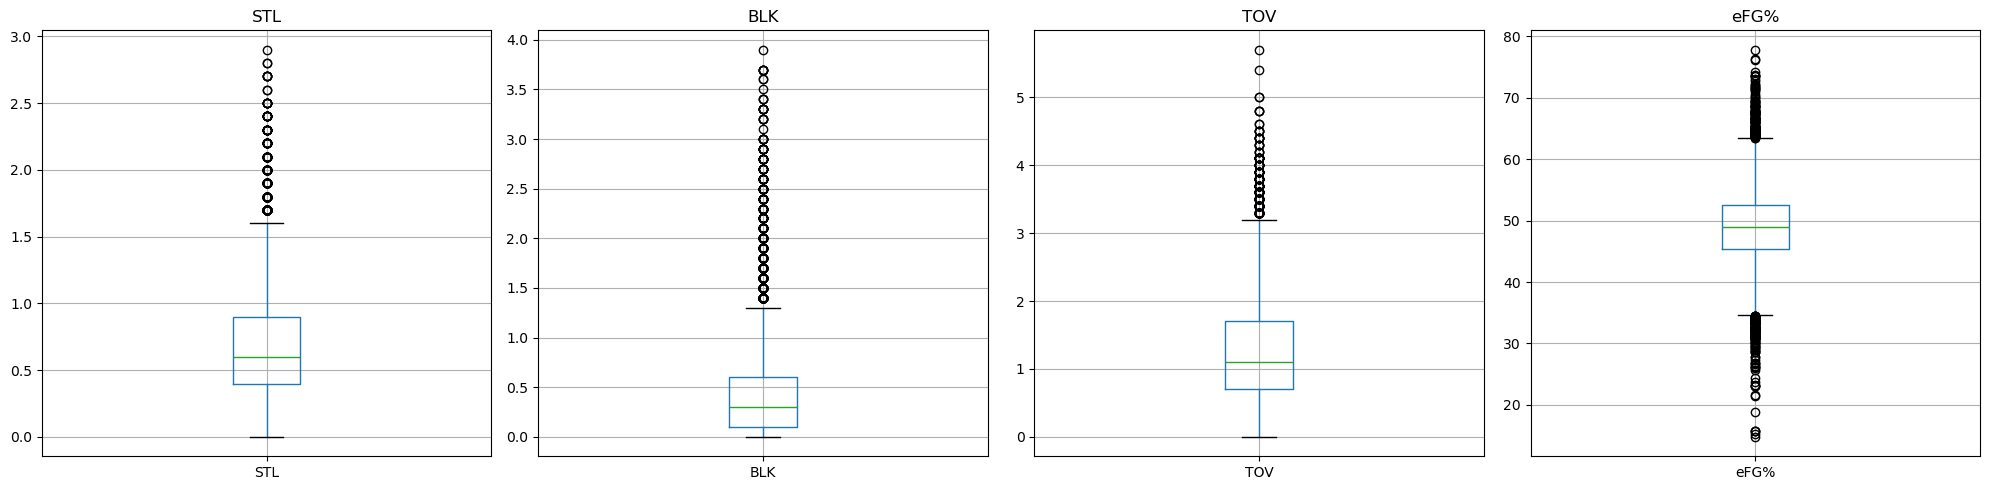

The box plots indicate outliers for all four traditional box score statistics, but the sufficient games played sample size indicates that these are either truly great or poor seasons.
====================== CLEANLINESS CHECK ======================
<StringArray>
['CHI', 'UTA', 'CHH', 'LAL', 'SAC', 'GSW', 'PHI', 'HOU', 'NYK', 'DEN', 'NJN',
 'SEA', 'IND', 'DET', 'MIL', 'MIN', 'ORL', 'MIA', 'TOR', 'PHO', 'ATL', 'WSB',
 'CLE', 'VAN', 'SAS', 'POR', 'BOS', 'DAL', 'LAC', 'WAS', 'MEM', 'NOH', 'CHA',
 'NOK', 'OKC', 'BRK', 'NOP', 'CHO']
Length: 38, dtype: str
All team abbreviations are valid, accepted 3 letter codes, but some differ slightly from the Kaggle dataset.
Map mismatched team abbreviations to the ones in the Kaggle dataset for easier merging.
Check new list of team three-letter abbreviations:
<StringArray>
['CHI', 'UTA', 'CHH', 'LAL', 'SAC', 'GSW', 'PHI', 'HOU', 'NYK', 'DEN', 'NJN',
 'SEA', 'IND', 'DET', 'MIL', 'MIN', 'ORL', 'MIA', 'TOR', 'PHX', 'ATL', 'WAS',
 'CLE', 'VAN', 'SAS', 'POR'

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in data
data_path = 'data/00-raw/player_per_game_raw.csv'
df_per_game = pd.read_csv(data_path)

# demonstrate tidiness
print("====================== TIDINESS CHECK ======================")
print ("Raw Dataframe Head:") 
print(df_per_game.head())
print(f"Dataframe shape: {df_per_game.shape}")
print(f"The number of rows that have the same player, season, and team abbreviation: {df_per_game[['Player', 'Team', 'season']].duplicated().sum()}")
print("The number of rows that have a missing player or team name:")
print(df_per_game[['Player', 'Team']].isnull().sum())
print("Show the players that are missing a team name:")
print(df_per_game[df_per_game['Team'].isnull()]['Player'])
print("We need to remove rows with missing team name because they do not represent an actual player's season.")
filtered_df_per_game = df_per_game.dropna(subset=['Team'])
print(f"The list of all column variables in the dataset: {df_per_game.columns}")
print("Each row represents the per game statistics of a player for a particular season and each column represents a unique statistic or player characteristic of the player's season.")

# demonstrate data size
print("====================== DATAFRAME SIZE ======================")
print(f"Dataframe size: {filtered_df_per_game.size}")
print(f"Dataframe rows: {filtered_df_per_game.shape[0]}")
print(f"Dataframe columns: {filtered_df_per_game.shape[1]}")

filtered_df_per_game = filtered_df_per_game[['Rk', 'Player', 'G', 'Team', 'Pos', 'STL', 'BLK', 'TOV', 'eFG%', 'season']].copy()
print ("Dataframe Head After Selecting Target Columns (Rk is used for deduplication and will be dropped):")
print(filtered_df_per_game.head())

# find out how much data is missing
print("====================== MISSINGNESS CHECK ======================")
print(f"Total amount of missing data: {filtered_df_per_game.isna().sum().sum()}")
print("Missing data per column:")
print(filtered_df_per_game.isnull().sum())
print("Players are missing data for effective field goal percentage, so we will check the games played for these players:")
print(df_per_game[df_per_game['eFG%'].isnull()]['G'].describe())
print("Similar to the advanced metric outliers in the Kaggle dataset, the missing entries for effective field goal percentage are linked to a low games played value.")
print("We will apply the same filter to filter out any players who have less than 20 games played after aggregating stats for players who were on multiple teams during a season.")

# deduplicate traded players and replace team placeholders
print("====================== DEDUPLICATION OF TRADED PLAYERS ======================")
print("Players who were traded mid-season have multiple entries. We will keep only the aggregate row and replace the placeholder team with the team they finished the season on.")

# get the last team each player appeared on in a season
last_team = (filtered_df_per_game[~filtered_df_per_game['Team'].str.endswith('TM')]
             .groupby(['Rk', 'Player', 'season'])['Team']
             .last()
             .reset_index()
             .rename(columns={'Team': 'final_team'}))

# keep only aggregate rows for traded players and single rows for non-traded players
filtered_df_per_game = filtered_df_per_game[
    filtered_df_per_game['Team'].str.endswith('TM') | 
    ~filtered_df_per_game.duplicated(subset=['Rk', 'Player', 'season'], keep=False)
]

# merge in the actual final team
filtered_df_per_game = filtered_df_per_game.merge(last_team, on=['Rk', 'Player', 'season'], how='left')

# replace placeholder team with final team where applicable
filtered_df_per_game['Team'] = filtered_df_per_game.apply(
    lambda row: row['final_team'] if pd.notna(row['final_team']) else row['Team'], axis=1
)
filtered_df_per_game = filtered_df_per_game.drop(columns='final_team')
filtered_df_per_game = filtered_df_per_game.drop(columns='Rk')

print(f"Rows after deduplication: {filtered_df_per_game.shape[0]}")
print("Each player now has exactly one row per season with their aggregate stats and the team they finished the season on.")
print("Check for invalid team abbreviations:")
print(filtered_df_per_game['Team'].unique())
print("There are no more entries indicating multiple teams as the team a player was on during a particular season.")

# apply games played filter
print("Filtering out players with fewer than 20 games played.")
filtered_df_per_game = filtered_df_per_game[filtered_df_per_game['G'] >= 20]
filtered_df_per_game = filtered_df_per_game.reset_index(drop=True)
print(f"Rows after games played filtering: {filtered_df_per_game.shape[0]}")
print(f"Total amount of missing data after filtering and deduplication: {filtered_df_per_game.isna().sum().sum()}")

# find and deal with outliers/suspicious entries
print("====================== SUSPICIOUS ENTRIES CHECK ======================")
print("Show descriptive statistics.")
print(filtered_df_per_game.describe())
print("Descriptive statistics show no impossible values for the blocks, steals, and turnovers per game nor for effective field goal percentage because all values are non-negative and effect field goal percentage has no entry exceeding 100%.")
print("Descriptive statistics also show the percentage columns are represented as decimals and must be transformed to percentages.")
pct_cols = ['eFG%']

filtered_df_per_game[pct_cols] = (filtered_df_per_game[pct_cols] * 100).round(1)
print("Show descriptive statistics after percentage transform.")
print(filtered_df_per_game.describe())

print("Create box plots for these four traditional box score statistics to visualize outliers after games played filtering")
# plot the boxplot with outliers after games played filter
cols = ['STL', 'BLK', 'TOV', 'eFG%']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for ax, col in zip(axes, cols):
    filtered_df_per_game.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()
print("The box plots indicate outliers for all four traditional box score statistics, but the sufficient games played sample size indicates that these are either truly great or poor seasons.")

# demonstrate cleanliness
print("====================== CLEANLINESS CHECK ======================")
print(filtered_df_per_game['Team'].unique())
print("All team abbreviations are valid, accepted 3 letter codes, but some differ slightly from the Kaggle dataset.")
print("Map mismatched team abbreviations to the ones in the Kaggle dataset for easier merging.")
filtered_df_per_game['Team'] = filtered_df_per_game['Team'].replace({
    'WSB': 'WAS',
    'BRK': 'BKN',
    'CHO': 'CHA',
    'PHO' : 'PHX'
})
print("Check new list of team three-letter abbreviations:")
print(filtered_df_per_game['Team'].unique())
print("Check for invalid season entries:")
print(filtered_df_per_game['season'].unique())
print("No entries need to be dropped.")
print(f"Cleaned Dataframe size: {filtered_df_per_game.size}")
print(f"Cleaned Dataframe rows: {filtered_df_per_game.shape[0]}")
print(f"Cleaned Dataframe columns: {filtered_df_per_game.shape[1]}")
print(f"Cleaned Dataframe missing value count: {filtered_df_per_game.isna().sum().sum()}")
print("Cleaned Dataframe data types:")
print(filtered_df_per_game.dtypes)

# save final dataset
print("====================== FINAL DATASET ======================")
print("The steps involved in the data cleaning were:")
print("1) Subset dataframe with the relevant columns.")
print("2) Ensure each player only has one entry per season by aggregating season stats and replacing team with the team they ended on for that season.")
print("3) Filter out players who played fewer than 20 games to deal with missing effective field goal percentage data.")
print("4) Map three letter team codes to match those in the Kaggle dataset for proper merging.")
print("Final Clean Dataset Head:")
print(filtered_df_per_game.head())
filtered_df_per_game.to_csv('data/02-processed/player_per_game_clean.csv', index=False)

### Dataset: Basketball Reference Advanced Player Statistics (1996-2022)

The player advanced stats data spans 26 seasons, each with its own URL on Basketball Reference. Since there are no direct CSV download links, we cannot use `get_data`. Instead, we use `pd.read_html()` to scrape the table directly from each page, looping over all 26 season URLs and concatenating the results into one dataframe.

The advanced player stats dataset sourced from Basketball Reference serves as the final supplemental dataset, providing the key advanced metrics that are central to the research question but absent from the three preceding datasets. The dataset contains advanced statistics for all NBA players across the 1996–97 to 2021–22 seasons, tracking 30 variables across 15,398 player seasons. The variables sourced from this dataset are Player Efficiency Rating (PER), Win Shares per 48 minutes (WS/48), turnover percentage (TOV%), free throw rate (FTr), Value Over Replacement Player (VORP), and Box Plus Minus (BPM). The games played (G) column will also be used to filter out outliers due to the presence of the numerous advanced metrics, such as VORP and BPM, which require a larger sample size represent player performance well. Finally, the rank (Rk) column will act as an index to be used to differentiate between two players with the same name who played in the same season.

Player Efficiency Rating is a per-minute summary measure of a player's overall performance that aggregates positive contributions while subtracting negative ones. The league average of PER is designed to be at 15 with values above 20 being considered All-Star caliber and values above 25 being considered MVP-caliber performances. Win Shares per 48 minutes estimates the number of wins a player contributes to their team per 48 minutes played, with the league average sitting around 0.100 and elite seasons typically exceeding 0.200. Turnover percentage estimates the number of turnovers a player commits per 100 possessions and captures a player’s turnover rate. Players who are considered more careless with the ball have a turnover percentage of around 15.0 while players and players with a lower turnover rate have a turnover percentage below 10.0. Free throw rate measures the number of free throw attempts a player generates per field goal attempt, capturing a player's ability to draw fouls and get to the line. The league average for free throw rate is about 0.250. Value Over Replacement Player estimates the number of points per 100 possessions a player contributes over a replacement-level player, defined as a player with a BPM of -2.0. Positive values of Value Over Replacement Player indicates above-replacement contribution and elite seasons typically exceed 4.0. Box Plus Minus estimates a player's contribution in points per 100 possessions relative to a league-average player, with 0.0 representing league average. Box Plus Minus values above 5.0 indicate All-Star caliber seasons and values above 8.0 indicating MVP-caliber seasons.

A major concern with this dataset is that advanced metrics such as BPM and VORP are known to be unreliable for players with limited games played or minutes, as the underlying calculations require sufficient sample sizes to stabilize. This may introduce noise at the edges of the modeling dataset for players with limited playing time. Furthermore, similar to the per-game dataset, players who were traded mid-season appear as multiple entries, requiring the same approach of retaining only the aggregate season row and aligning the team entry with the team the player finished the season on.

In [9]:
# uncomment if you dont have lxml otherwise read_html wont work
# !pip install lxml

# helper function to set the value of the seasons column in the data frame 
def season_label(end_year):
    return f"{end_year - 1}-{str(end_year)[-2:]}"

ADV_RAW_PATH = 'data/00-raw/player_advanced_raw.csv'

if os.path.exists(ADV_RAW_PATH): 
    print('ADV data already downloaded, skipping.') 
else:
    frames = []
    for yr in range(1997, 2023):
        url = f"https://www.basketball-reference.com/leagues/NBA_{yr}_advanced.html"
        try:
            tables = pd.read_html(url)
            df = tables[0] # only one table per link so no need for using webscraping tools for table id for this dataset
            df['season'] = season_label(yr)
            frames.append(df)
            print(f'{yr} OK')
            time.sleep(3.5)  
        except Exception as e:
            print(f'{yr} ERROR: {e}')

    df_adv_raw = pd.concat(frames, ignore_index=True)
    df_adv_raw.head(5)
    df_adv_raw.to_csv('data/00-raw/player_advanced_raw.csv', index=False)
    print(f'player_advanced_raw.csv is ready in data/00-raw')

ADV data already downloaded, skipping.


====================== TIDINESS CHECK ======================
Raw Dataframe Head:
    Rk            Player   Age Team Pos     G    GS      MP   PER    TS%  ...  \
0  1.0         Glen Rice  29.0  CHH  SF  79.0  78.0  3362.0  19.7  0.605  ...   
1  2.0  Latrell Sprewell  26.0  GSW  SG  80.0  79.0  3353.0  19.7  0.570  ...   
2  3.0      Juwan Howard  23.0  WSB  SF  82.0  82.0  3324.0  16.1  0.529  ...   
3  4.0  Damon Stoudamire  23.0  TOR  PG  81.0  81.0  3311.0  18.1  0.516  ...   
4  5.0       Gary Payton  28.0  SEA  PG  82.0  82.0  3213.0  21.8  0.545  ...   

   OWS  DWS    WS  WS/48  OBPM  DBPM  BPM  VORP                     Awards  \
0  9.6  1.2  10.8  0.154   3.9  -2.1  1.8   3.2              MVP-5,AS,NBA2   
1  7.0  1.1   8.1  0.115   3.8  -1.1  2.7   4.0                         AS   
2  3.3  3.7   7.0  0.101   0.1  -0.5 -0.3   1.4                        NaN   
3  5.8  1.8   7.6  0.110   3.4  -1.6  1.8   3.1                        NaN   
4  8.2  4.7  12.9  0.193   4.4   1.1  5.5 

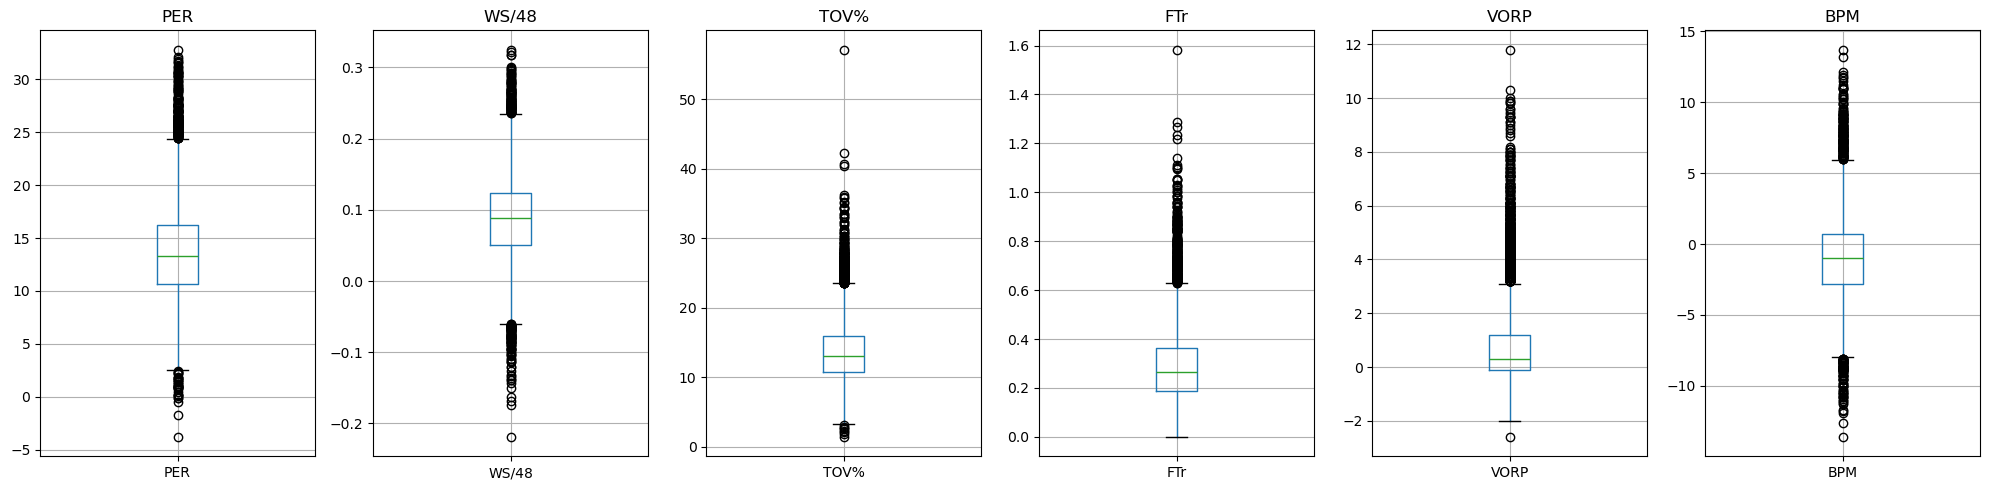

The box plots indicate outliers for all six advanced metrics, but the sufficient games played sample size indicates that these are either truly great or poor seasons.
====================== CLEANLINESS CHECK ======================
<StringArray>
['CHH', 'GSW', 'WSB', 'TOR', 'SEA', 'NJN', 'CLE', 'PHI', 'MIL', 'DET', 'ATL',
 'MIA', 'MIN', 'SAC', 'CHI', 'POR', 'IND', 'UTA', 'LAL', 'BOS', 'DEN', 'NYK',
 'HOU', 'LAC', 'VAN', 'DAL', 'PHO', 'ORL', 'SAS', 'WAS', 'MEM', 'NOH', 'CHA',
 'NOK', 'OKC', 'BRK', 'NOP', 'CHO']
Length: 38, dtype: str
All team abbreviations are valid, accepted 3 letter codes, but some differ slightly from the Kaggle dataset.
Map mismatched team abbreviations to the ones in the Kaggle dataset for easier merging.
Check new list of team three-letter abbreviations:
<StringArray>
['CHH', 'GSW', 'WAS', 'TOR', 'SEA', 'NJN', 'CLE', 'PHI', 'MIL', 'DET', 'ATL',
 'MIA', 'MIN', 'SAC', 'CHI', 'POR', 'IND', 'UTA', 'LAL', 'BOS', 'DEN', 'NYK',
 'HOU', 'LAC', 'VAN', 'DAL', 'PHX', 'ORL', '

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load in data
data_path = 'data/00-raw/player_advanced_raw.csv'
df_advanced = pd.read_csv(data_path)

# demonstrate tidiness
print("====================== TIDINESS CHECK ======================")
print ("Raw Dataframe Head:") 
print(df_advanced.head())
print(f"Dataframe shape: {df_advanced.shape}")
print(f"The number of rows that have the same player, season, and team abbreviation: {df_advanced[['Player', 'Team', 'season']].duplicated().sum()}")
print("The number of rows that have a missing player or team name:")
print(df_advanced[['Player', 'Team']].isnull().sum())
print("Show the players that are missing a team name:")
print(df_advanced[df_advanced['Team'].isnull()]['Player'])
print("We need to remove rows with missing team name because they do not represent an actual player's season.")
filtered_df_advanced = df_advanced.dropna(subset=['Team'])
print(f"The list of all column variables in the dataset: {df_advanced.columns}")
print("Each row represents the advanced metrics of a player for a particular season and each column represents a unique metric or player characteristic of the player's season.")

# demonstrate data size
print("====================== DATAFRAME SIZE ======================")
print(f"Dataframe size: {filtered_df_advanced.size}")
print(f"Dataframe rows: {filtered_df_advanced.shape[0]}")
print(f"Dataframe columns: {filtered_df_advanced.shape[1]}")

filtered_df_advanced = filtered_df_advanced[['Rk', 'Player', 'G', 'Team', 'PER', 'WS/48', 'TOV%', 'FTr', 'VORP', 'BPM', 'season']].copy()
print ("Dataframe Head After Selecting Target Columns (Rk is used for deduplication and will be dropped):")
print(filtered_df_advanced.head())

# find out how much data is missing
print("====================== MISSINGNESS CHECK ======================")
print(f"Total amount of missing data: {filtered_df_advanced.isna().sum().sum()}")
print("Missing data per column:")
print(filtered_df_advanced.isnull().sum())
print("Players are missing data in numerous columns, but we will look at free throw rate first and check the games played for these players:")
print(filtered_df_advanced[filtered_df_advanced['FTr'].isnull()]['G'].describe())
print("Similar to the advanced metric outliers in the Kaggle dataset and effective field goal percentage missing entries in the per game stats dataset, the missing entries for free throw rate are linked to a low games played value.")
print("We will apply the same filter to filter out any players who have less than 20 games played after aggregating stats for players who were on multiple teams during a season.")

# deduplicate traded players and replace team placeholders
print("====================== DEDUPLICATION OF TRADED PLAYERS ======================")
print("Players who were traded mid-season have multiple entries. We will keep only the aggregate row and replace the placeholder team with the team they finished the season on.")

# get the last team each player appeared on in a season
last_team = (filtered_df_advanced[~filtered_df_advanced['Team'].str.endswith('TM')]
             .groupby(['Rk', 'Player', 'season'])['Team']
             .last()
             .reset_index()
             .rename(columns={'Team': 'final_team'}))

# keep only aggregate rows for traded players and single rows for non-traded players
filtered_df_advanced = filtered_df_advanced[
    filtered_df_advanced['Team'].str.endswith('TM') | 
    ~filtered_df_advanced.duplicated(subset=['Rk', 'Player', 'season'], keep=False)
]

# merge in the actual final team
filtered_df_advanced = filtered_df_advanced.merge(last_team, on=['Rk', 'Player', 'season'], how='left')

# replace placeholder team with final team where applicable
filtered_df_advanced['Team'] = filtered_df_advanced.apply(
    lambda row: row['final_team'] if pd.notna(row['final_team']) else row['Team'], axis=1
)
filtered_df_advanced = filtered_df_advanced.drop(columns='final_team')
filtered_df_advanced = filtered_df_advanced.drop(columns='Rk')
print(f"Rows after deduplication: {filtered_df_advanced.shape[0]}")
print("Each player now has exactly one row per season with their aggregate stats and the team they finished the season on.")
print("Check for invalid team abbreviations:")
print(filtered_df_advanced['Team'].unique())

print("There are no more entries indicating multiple teams as the team a player was on during a particular season.")

# apply games played filter
print("Filtering out players with fewer than 20 games played.")
filtered_df_advanced = filtered_df_advanced[filtered_df_advanced['G'] >= 20]
filtered_df_advanced = filtered_df_advanced.reset_index(drop=True)
print(f"Rows after games played filtering: {filtered_df_advanced.shape[0]}")
print(f"Total amount of missing data after filtering and deduplication: {filtered_df_advanced.isna().sum().sum()}")
print(filtered_df_advanced.isnull().sum())

# find and deal with outliers/suspicious entries
print("====================== SUSPICIOUS ENTRIES CHECK ======================")
print("Show descriptive statistics.")
print(filtered_df_advanced.describe())
print("Descriptive statistics show no impossible values for PER, WS/48, TOV%, FTr, VORP, and BPM because TOV% and FTr are the only values that cannot be negative and both only have non-negative values in the dataset.")

print("Create box plots for these six advanced metrics to visualize outliers after games played filtering")
# plot the boxplot with outliers after games played filter
cols = ['PER', 'WS/48', 'TOV%', 'FTr', 'VORP', 'BPM']

fig, axes = plt.subplots(1, len(cols), figsize=(20, 5))

for ax, col in zip(axes, cols):
    filtered_df_advanced.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()
print("The box plots indicate outliers for all six advanced metrics, but the sufficient games played sample size indicates that these are either truly great or poor seasons.")

# demonstrate cleanliness
print("====================== CLEANLINESS CHECK ======================")
print(filtered_df_advanced['Team'].unique())
print("All team abbreviations are valid, accepted 3 letter codes, but some differ slightly from the Kaggle dataset.")
print("Map mismatched team abbreviations to the ones in the Kaggle dataset for easier merging.")
filtered_df_advanced['Team'] = filtered_df_advanced['Team'].replace({
    'WSB': 'WAS',
    'BRK': 'BKN',
    'CHO': 'CHA',
    'PHO' : 'PHX'
})
print("Check new list of team three-letter abbreviations:")
print(filtered_df_advanced['Team'].unique())
print("Check for invalid season entries:")
print(filtered_df_advanced['season'].unique())
print("No entries need to be dropped.")
print(f"Cleaned Dataframe size: {filtered_df_advanced.size}")
print(f"Cleaned Dataframe rows: {filtered_df_advanced.shape[0]}")
print(f"Cleaned Dataframe columns: {filtered_df_advanced.shape[1]}")
print(f"Cleaned Dataframe missing value count: {filtered_df_advanced.isna().sum().sum()}")
print("Cleaned Dataframe data types:")
print(filtered_df_advanced.dtypes)

# save final dataset
print("====================== FINAL DATASET ======================")
print("The steps involved in the data cleaning were:")
print("1) Subset dataframe with the relevant columns.")
print("2) Ensure each player only has one entry per season by aggregating season stats and replacing team with the team they ended on for that season.")
print("3) Filter out players who played fewer than 20 games to deal with multiple missing advanced metric columns.")
print("4) Map three letter team codes to match those in the Kaggle dataset for proper merging.")
print("Final Clean Dataset Head:")
print(filtered_df_advanced.head())
filtered_df_advanced.to_csv('data/02-processed/player_advanced_clean.csv', index=False)

### Merging Data

The cells below will show the merging of the four individual tidy and clean datasets into one master tidy and clean dataset as well as showing how we dealt with small merging issues.

In [11]:
import pandas as pd
import unicodedata
import re

# load cleaned datasets
df_kaggle = pd.read_csv('data/02-processed/all_seasons_clean.csv')
df_mvp = pd.read_csv('data/02-processed/mvp_voting_clean.csv')
df_per_game = pd.read_csv('data/02-processed/player_per_game_clean.csv')
df_advanced = pd.read_csv('data/02-processed/player_advanced_clean.csv')

# rename Kaggle columns to match BBRef datasets naming for merging
df_kaggle = df_kaggle.rename(columns={'player_name': 'Player', 'team_abbreviation': 'Team'})

# to avoid name mismatched based on different name abbreviations, diacritics, etc
def normalize_name(name):
    # diacritics ('Luka Dončić' → 'Luka Doncic')
    name = unicodedata.normalize('NFKD', str(name))
    name = ''.join(c for c in name if not unicodedata.combining(c))
    name = name.replace('.', '').replace('-', ' ').strip()
    #suffixes
    name = re.sub(r'\b(jr|sr|ii|iii|iv)\b', '', name, flags=re.IGNORECASE).strip()
    return name.lower()

manual_map = {
    'Clar. Weatherspoon': 'Clarence Weatherspoon',
    'Richard Manning': 'Rich Manning',
    'Michael Sweetney': 'Mike Sweetney',
    'Jeffery Taylor': 'Jeff Taylor',
    'Nicolas Claxton': 'Nic Claxton',
    'Ike Austin': 'Isaac Austin',
    'Slava Medvedenko': 'Stanislav Medvedenko',
    'Pooh Jeter': 'Eugene Jeter',
    'Dan Schayes': 'Danny Schayes',
    'Steven Smith': 'Steve Smith',
    'Charles R. Jones': 'Charles Jones',
    'Wang Zhi-zhi': 'Wang Zhizhi',
    'Boniface Ndong': "Boniface N'Dong",
    'Vitor Faverani': 'Vítor Luiz Faverani',
    'Alekesej Pokusevski': 'Aleksej Pokusevski',  
    'Kiwane Garris': 'Kiwane Lemorris Garris',
    'Enes Kanter': 'Enes Freedom',
    'Ha Ha': 'Ha Seung-Jin',
    'Flip Murray': 'Ronald Murray',
    'Omer Asik': 'Ömer Aşık',
    'Kenyon Martin Jr.' : 'KJ Martin'
}

df_kaggle['Player'] = df_kaggle['Player'].replace(manual_map)


# Player_key --> helper column with the normalized version of the player name
df_kaggle['Player_key'] = df_kaggle['Player'].apply(normalize_name)
df_per_game['Player_key'] = df_per_game['Player'].apply(normalize_name)
df_advanced['Player_key'] = df_advanced['Player'].apply(normalize_name)
df_mvp['Player_key'] = df_mvp['Player'].apply(normalize_name)


# merge Kaggle + per-game stats
df_merged = pd.merge(
    df_kaggle,
    df_per_game[['Player_key', 'season', 'Pos', 'STL', 'BLK', 'TOV', 'eFG%']],
    on=['Player_key', 'season'],
    how='left'
)
# merge in advanced stats
df_merged = pd.merge(
    df_merged,
    df_advanced[['Player_key', 'season', 'PER', 'WS/48', 'TOV%', 'FTr', 'VORP', 'BPM']],
    on=['Player_key', 'season'],
    how='left'
)

# merge in MVP vote share
df_merged = pd.merge(
    df_merged,
    df_mvp[['Player_key', 'season', 'share']],
    on=['Player_key', 'season'],
    how='left'
)


df_merged['share'] = df_merged['share'].fillna(0)
df_merged = df_merged.drop(columns='Player_key')
print(f"Merged shape: {df_merged.shape}")
print(f"Missing values:\n{df_merged.isnull().sum()}")



df_merged.to_csv('data/02-processed/merged_clean.csv', index=False)
df_merged = pd.read_csv('data/02-processed/merged_clean.csv')
print(f"The number of entires with non-zero MVP vote share matches with the size of the MVP vote share dataset: {df_merged['share'][df_merged['share'] != 0].count()}")
print(f"Total rows with missing BBRef data: {df_merged['Pos'].isna().sum()}")
print(f"\nUnique players with missing data is an empty list:")
print(df_merged[df_merged['Pos'].isna()]['Player'].unique())

Merged shape: (10284, 24)
Missing values:
Player        0
Team          0
gp            0
pts           0
reb           0
ast           0
net_rating    0
usg_pct       0
ts_pct        0
oreb_pct      0
dreb_pct      0
season        0
Pos           0
STL           0
BLK           0
TOV           0
eFG%          0
PER           0
WS/48         0
TOV%          0
FTr           0
VORP          0
BPM           0
share         0
dtype: int64
The number of entires with non-zero MVP vote share matches with the size of the MVP vote share dataset: 373
Total rows with missing BBRef data: 0

Unique players with missing data is an empty list:
<StringArray>
[]
Length: 0, dtype: str


In [12]:
print(df_merged.describe())
print("We can see that after merging, there are 10284 entries for each of the 24 columns and none of the traditional nor advanced metrics contain any impossible values.")

                 gp           pts           reb           ast    net_rating  \
count  10284.000000  10284.000000  10284.000000  10284.000000  10284.000000   
mean      59.593543      9.170867      3.933956      2.027869     -1.092950   
std       18.103856      5.884902      2.459299      1.842393      6.448199   
min       20.000000      0.300000      0.100000      0.000000    -40.000000   
25%       46.750000      4.600000      2.100000      0.700000     -5.300000   
50%       63.000000      7.800000      3.300000      1.400000     -0.900000   
75%       76.000000     12.400000      5.100000      2.700000      3.200000   
max       85.000000     36.100000     16.100000     11.700000     19.500000   

            usg_pct        ts_pct      oreb_pct      dreb_pct           STL  \
count  10284.000000  10284.000000  10284.000000  10284.000000  10284.000000   
mean      18.688672     52.675924      5.444078     14.273425      0.709277   
std        4.890955      5.788561      3.831347    

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [13]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION
processed_datafiles = [
    { 'url': 'https://drive.google.com/uc?export=download&id=1VuhAbDh00i2_v1fMyvocOLzmzc01svrQ', 'filename': 'merged_clean.csv'}
]

get_data.get_raw(processed_datafiles,destination_directory='data/02-processed/')

df_merged = pd.read_csv('data/02-processed/merged_clean.csv')
df_merged.head()

Overall Download Progress: 100%|██████████| 1/1 [00:02<00:00,  2.26s/it]

Successfully downloaded: merged_clean.csv


,Player,Team,gp,pts,reb,ast,net_rating,usg_pct,ts_pct,oreb_pct,...,BLK,TOV,eFG%,PER,WS/48,TOV%,FTr,VORP,BPM,share
0,Randy Livingston,HOU,64,3.9,1.5,2.4,0.3,16.9,48.7,4.2,...,0.2,1.6,45.6,8.3,0.012,28.4,0.284,-0.4,-3.7,0.0
1,George Lynch,VAN,41,8.3,6.4,1.9,-8.2,17.5,51.2,10.6,...,0.4,1.6,48.5,15.4,0.070,16.1,0.333,0.3,-1.0,0.0
2,George McCloud,LAL,64,10.2,2.8,1.7,-2.7,20.6,52.7,2.7,...,0.1,1.0,49.7,14.8,0.102,8.9,0.175,0.9,0.3,0.0
3,George Zidek,DEN,52,2.8,1.7,0.3,-14.1,19.5,50.0,10.2,...,0.1,0.5,41.5,10.2,0.034,15.9,0.483,-0.5,-6.9,0.0
4,Gerald Wilkins,ORL,80,10.6,2.2,2.2,-5.8,20.3,50.3,3.1,...,0.2,1.5,46.9,11.2,0.046,12.7,0.250,-0.3,-2.5,0.0


#### Time series plots of traditional/advanced metrics across the 26 seasons

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
# Only the players who got votes because many players got 0 MVP vote share
# Those players dilute our analysis (at this point) which focuses on how has the MVP vote share changed over time
df_mvp = df_merged[df_merged['share'] > 0].copy()

# Converting string seasons to int e.g. "1996-97" to 1996 
def sorting_season (season: str): 
    season = season.split('-')[0]
    int_season = int(season)
    return int_season

season_order = sorted(df_mvp['season'].unique(), key=sorting_season)
x = list(range(len(season_order)))
season_to_x = {s: i for i, s in enumerate(season_order)}

# the era split line 
era_x = season_to_x.get('2003-04', None)

def season_ts(metric, seasons):
    # median, 50th, and 75th percentile
    medians, q1s, q3s = [], [], []
    for s in seasons:
        vals = df_mvp[df_mvp['season'] == s][metric].dropna()
        medians.append(vals.median())
        q1s.append(vals.quantile(0.25))
        q3s.append(vals.quantile(0.75))
    return np.array(medians), np.array(q1s), np.array(q3s)

traditional_metrics = ['pts', 'reb', 'ast', 'STL', 'BLK', 'TOV', 'eFG%']
traditional_labels  = ['Points per Game', 'Rebounds per Game', 'Assists per Game', 'Steals per Game', 
                       'Blocks per Game', 'Turnovers per Game', 'Effective Field Goal %']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()


for i, (metric, label) in enumerate(zip(traditional_metrics, traditional_labels)):
    ax = axes[i]
    meds, q1s, q3s = season_ts(metric, season_order)
    ax.plot(x, meds, color="#1e79be", linewidth=3, label='Median')
    ax.fill_between(x, q1s, q3s, alpha=0.20, color='#1e79be', label='Interquartile Range')


    if era_x is not None:
        ax.axvline(x=era_x + 0.5, color="#c51b1b", linestyle='--', linewidth=1.5, label='2004 Era Split')
    

    ax.set_xticks(range(0, len(season_order), 4))
    ax.set_xticklabels([season_order[i] for i in range(0, len(season_order), 4)], rotation=45, ha='right')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel(label, fontsize=9)
    ax.set_xlabel('Season', fontsize=9)
    







1996


#### Section 3 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.


In [15]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

Instructions: Keep the contents of this cell. For each item on the checklist
-  put an X there if you've considered the item
-  IF THE ITEM IS RELEVANT place a short paragraph after the checklist item discussing the issue.
  
Items on this checklist are meant to provoke discussion among good-faith actors who take their ethical responsibilities seriously. Your teams will document these discussions and decisions for posterity using this section.  You don't have to solve these problems, you just have to acknowledge any potential harm no matter how unlikely.

Here is a [list of real world examples](https://deon.drivendata.org/examples/) for each item in the checklist that can refer to.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

>  When players sign contracts to play in the NBA, they give their consent for the NBA to publish certain data about them. This data includes the traditional box score statistics and advanced metrics which players know will be used by the media for NBA awards and to be viewed publicly by the fans. The data is originally pulled from the official NBA website, which the NBA players know is fully viewable by fans for interpretation.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

>  We created our time frame to start with the 1996-1997 season because the NBA started tracking detailed play-by-play data during this season. We wanted to limit the human bias (e.g. inflating stats to their favorite team) or error that may come from relying on the mostly human scorekeeper data that exists before the 1996-1997 season.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

>  Our dataset will not include any PII past what is available on the NBA.com player statistics. The existence of the player name in our dataset is needed for attributing player stats and MVP vote share to each individual player. We will remove the player height, player weight, and college columns from the Kaggle dataset to further limit PII exposure.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

>  Our dataset will contain the Nationality of each player to allow testing for a bias in voting share against international (non-American) players.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

>  All of the data we are using is retrieved from public datasets that originated from the publicly available NBA player statistics, so there is no sensitive data that requires explicit encryption. The actual data will only be available among the group members of this project and the instruction team of this course.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

>  The data in this project will solely be used for this academic project. The data will be locked in this private GitHub repo once the analysis of the data for this academic project is finished.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

>  We read prior works that reference the narrative surrounding a player's season as a factor to MVP vote share and realize that our model will not consider this. We will adjust our analysis to reflect on our findings in the context for each NBA season or era, if applicable, and highlight this shortcoming of our model in the conclusion.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

>  The player metrics of our dataset favor offensive production and high-usage rate players which disadvantages more defensive-minded players. We will include the team wins linked to a specific player's team as a variable and use the win shares statistic to better capture how a player contributes to winning.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

>  We will be careful when creating our visualizations, summary statistics, and reports to honestly represent the underlying data. For example, we will take the context of shortened lock out seasons into consideration to scale team wins up to an 82 season.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

>  We do not anticipate using any datasets with PII (other than player names), nor do we hypothesize that any PII datapoints would be relevant predictors.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

>  We will be very explicit about the steps of our analyses and will carefully explain the rationale of each step to make results easy to reproduce.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

>  The variables in our dataset are collected based on the objective player performance in each game of an NBA season to ensure our model does not rely on discriminatory variables. We will also not use any biometric or PII data when creating our model.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

>  We will manually analyze the results of our model to see if it unfairly favors players on big market teams or even players playing certain positions and extend that to the context of potential voter bias.

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

>  We are building a model to decide the strongest predictors of NBA MVP vote share. Because vote share is determined by media voters, optimizing our model will likely capture media voting patterns, which is what we are trying to track.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

>  The model we will use is regression-based which means that the coefficients can be interpreted as the strength of each variable on MVP vote share. We will also contextualize the model's decisions in the narratives surrounding each era or season to account for the difficult in quantifying such narratives.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

>   We will clearly communicate the fact that our model is reliant on previous media voting which may capture human biases instead of accurately quantifying a player's value. 

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

>  Due to the NBA MVP being awarded only once a year, we will have the opportunity to compare our model's predictions with the vote share from each subsequent season and address discrepancies on a yearly basis.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

>  We will monitor if narratives based on our model are used to denounce the value of NBA players and will emphasize that our model is based on innately subjective voting data rather than objective player value.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

>  Our model could be used to determine future the vote share in future NBA MVP races when its intended purpose was to analyze the importance of player metrics in prior MVP races. We will clearly specify the scope of our model to be the time frame of 1996 to 2022.

## Team Expectations 

* Always Keep the group up to date regarding project progress and possible situations that might happen. If you find yourself struggling with meeting a deadline or being unable to work on your part, let the group know as soon as possible so we can plan accordingly.
* Be Civil and Respectful to each other. If a group member is acting irrationally towards the others, the group will try to resolve the possible situation before contacting the course instructor/TA’s for assistance. When providing feedback to group members on work, make sure to be respectful with providing your opinion on their work.
* Project/Group decisions will be made based on majority agreement. If one member isn’t too content with a decision or wants to make an alteration to it, they are free to present their alternative to it, and come to a mutual agreement with the group in updating the decision to fit everyone.
* Check the Discord group chat regularly (around twice a day). We want to receive timely feedback from each other. Try to reply to or acknowledge (even with a reaction) the messages of your teammates.


## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 4/22  |  Asynchronous | Read & Think about COGS 108 expectations; brainstorm topics/questions  | Discuss and decide on final project topic; discuss hypothesis; begin background research; make team expectations | 
| 4/26  |  Asynchronous |  Do background research on topic | Discuss ideal dataset(s) and ethics; assign project proposal components; share background references | 
| 4/29  |  3 PM |  Complete assigned project proposal components | Find potential real datasets; edit and merge project proposal components; submit proposal | 
| 5/6  | 10 PM  | Search for and finalize datasets to use  | Discuss Wrangling and possible analytical approaches; assign group members to lead EDA |
| 5/13  | 3 PM  | Import & Wrangle Data (Conner & Ghaida); address proposal feedback | Refine data description; start basic EDA; submit Data checkpoint; begin Descriptive Analysis |
| 5/20  | 10 PM  | Completed assigned EDA part (everyone); background research on Analysis techniques | Review/Edit EDA; discuss and finalize Analysis plan |
| 5/27  | 3 PM  | Finalize EDA; begin Analysis (Guthry & Ari)  | Submit EDA checkpoint; discuss end of quarter busy times/roadblocks; Analysis progress check-in |
| 6/1  | 10 PM  | First Draft of Analysis (Guthry & Ari) | Discuss/edit/finalize Analysis; check overall project flow; draft results/conclusion/discussion |
| 6/5  | 10 PM  | Finalize results/conclusion/discussion; prepare target visualizations for Final Video| Discuss/edit full project; record Final Video |
| 6/10  | Before 11:59 PM  | Edit/Finalize Video (George) | Turn in Final Project & Group Project Surveys |